# 03 — Analyse descriptive & Tests statistiques

**Objectif** : tester si underperformance est associee a plus de vulnerabilite defensive.

## Checklist
- [ ] Test brut traite vs controle
- [ ] Stratification par score state
- [ ] Sensibilite au seuil
- [ ] Test de permutation
- [ ] Correction tests multiples
- [ ] Heatmap conditionnelle

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.figsize': (14, 6),
    'figure.dpi': 100
})
print('Setup OK')

Setup OK


In [2]:
timeline = pd.read_parquet('../data/processed/timelines.parquet')
episodes = pd.read_parquet('../data/processed/episodes.parquet')

print(f'Timeline : {timeline.shape}')
print(f'Episodes : {episodes.shape}')
print(f'Matchs   : {timeline["match_id"].nunique()}')

Timeline : (6406, 40)
Episodes : (107, 29)
Matchs   : 35


In [3]:
from src.features import UnderperformanceFeatures

feat = UnderperformanceFeatures()
tl = feat.filter_complete_windows(timeline, window=10)
print(f'Observations avec fenetre 10min complete : {len(tl)}')

16:13:31 │ INFO    │ Filtrage fenetre 10min : 700 obs. tronquees supprimees (10.9%)


Observations avec fenetre 10min complete : 5706


---
## 1. Test brut traite vs controle

In [4]:
from src.analysis import WindowAnalysis

wa = WindowAnalysis()

baseline = wa.compute_baseline(tl, window=10)
print('BASELINE (toutes observations) :')
print(f'  P(conceder 10min) : {baseline["p_concede"]:.4f}')
print(f'  xGA moyen 10min   : {baseline["mean_xga"]:.4f}')
print(f'  Tirs adv. 10min   : {baseline["mean_opp_shots"]:.3f}')
print(f'  N observations    : {baseline["n"]}')

BASELINE (toutes observations) :
  P(conceder 10min) : 0.1607
  xGA moyen 10min   : 0.1663
  Tirs adv. 10min   : 1.271
  N observations    : 5706


In [5]:
results_05 = wa.event_study(tl, threshold=0.5, window=10)
wa.print_event_study(results_05, label='EVENT STUDY - Seuil 0.5')


  EVENT STUDY - Seuil 0.5

  P(conceder dans 10 min) :
    Traite   : 0.0968  (n=857)
    Controle : 0.1720  (n=4849)
    Diff     : -0.0751  (RR=0.563)
    z=-5.522, p=0.0000 *

  xGA moyen (10 min) :
    Traite   : 0.1305
    Controle : 0.1726
    Diff     : -0.0421  (Cohen's d=-0.177)
    t=-5.295, p=0.0000 *

  Tirs adverses (10 min) :
    Traite   : 1.147
    Controle : 1.293
    Diff     : -0.146
    t=-3.265, p=0.0011 *


In [6]:
results_03 = wa.event_study(tl, threshold=0.3, window=10)
wa.print_event_study(results_03, label='EVENT STUDY - Seuil 0.3')


  EVENT STUDY - Seuil 0.3

  P(conceder dans 10 min) :
    Traite   : 0.1569  (n=1440)
    Controle : 0.1620  (n=4266)
    Diff     : -0.0050  (RR=0.969)
    z=-0.450, p=0.6529 

  xGA moyen (10 min) :
    Traite   : 0.1643
    Controle : 0.1669
    Diff     : -0.0026  (Cohen's d=-0.010)
    t=-0.316, p=0.7519 

  Tirs adverses (10 min) :
    Traite   : 1.168
    Controle : 1.306
    Diff     : -0.138
    t=-3.725, p=0.0002 *


---
## 2. Stratification par score state

**Le test le plus important.** Si l'effet disparait quand on controle le score, l'adage est un artefact du game state.

In [7]:
print('STRATIFICATION PAR SCORE STATE (seuil 0.5)')
print('=' * 65)
strat_05 = wa.stratified_analysis(tl, threshold=0.5, window=10)
for state, res in strat_05.items():
    wa.print_event_study(res, label=f'Score state : {state.upper()}')

STRATIFICATION PAR SCORE STATE (seuil 0.5)

  Score state : DRAWING

  P(conceder dans 10 min) :
    Traite   : 0.1237  (n=372)
    Controle : 0.1649  (n=2244)
    Diff     : -0.0412  (RR=0.750)
    z=-2.014, p=0.0440 *

  xGA moyen (10 min) :
    Traite   : 0.1447
    Controle : 0.1662
    Diff     : -0.0216  (Cohen's d=-0.085)
    t=-1.550, p=0.1217 

  Tirs adverses (10 min) :
    Traite   : 1.113
    Controle : 1.275
    Diff     : -0.162
    t=-2.289, p=0.0225 *

  Score state : WINNING

  P(conceder dans 10 min) :
    Traite   : 0.0259  (n=193)
    Controle : 0.1405  (n=1352)
    Diff     : -0.1146  (RR=0.184)
    z=-4.486, p=0.0000 *

  xGA moyen (10 min) :
    Traite   : 0.1271
    Controle : 0.1330
    Diff     : -0.0058  (Cohen's d=-0.027)
    t=-0.408, p=0.6837 

  Tirs adverses (10 min) :
    Traite   : 1.280
    Controle : 1.179
    Diff     : +0.101
    t=1.019, p=0.3094 

  Score state : LOSING

  P(conceder dans 10 min) :
    Traite   : 0.1096  (n=292)
    Controle : 0.

In [8]:
print('STRATIFICATION PAR SCORE STATE (seuil 0.3)')
print('=' * 65)
strat_03 = wa.stratified_analysis(tl, threshold=0.3, window=10)
for state, res in strat_03.items():
    wa.print_event_study(res, label=f'Score state : {state.upper()}')

STRATIFICATION PAR SCORE STATE (seuil 0.3)

  Score state : DRAWING

  P(conceder dans 10 min) :
    Traite   : 0.1626  (n=621)
    Controle : 0.1579  (n=1995)
    Diff     : +0.0047  (RR=1.030)
    z=0.282, p=0.7776 

  xGA moyen (10 min) :
    Traite   : 0.1776
    Controle : 0.1587
    Diff     : +0.0189  (Cohen's d=0.067)
    t=1.352, p=0.1767 

  Tirs adverses (10 min) :
    Traite   : 1.098
    Controle : 1.300
    Diff     : -0.202
    t=-3.463, p=0.0006 *

  Score state : WINNING

  P(conceder dans 10 min) :
    Traite   : 0.0433  (n=254)
    Controle : 0.1425  (n=1291)
    Diff     : -0.0992  (RR=0.304)
    z=-4.353, p=0.0000 *

  xGA moyen (10 min) :
    Traite   : 0.1147
    Controle : 0.1357
    Diff     : -0.0210  (Cohen's d=-0.095)
    t=-1.621, p=0.1057 

  Tirs adverses (10 min) :
    Traite   : 1.130
    Controle : 1.204
    Diff     : -0.074
    t=-0.887, p=0.3758 

  Score state : LOSING

  P(conceder dans 10 min) :
    Traite   : 0.2018  (n=565)
    Controle : 0.195

In [9]:
# Score nul uniquement (test le plus propre)
tl_drawing = tl[tl['score_state'] == 'drawing']
tl_00 = tl_drawing[tl_drawing['score_diff'] == 0]
n_treated_00 = len(tl_00[tl_00['cum_underperf'] >= 0.3])
n_control_00 = len(tl_00[tl_00['cum_underperf'] < 0.3])
print(f'Matchs a score nul :')
print(f'  Traite (underperf >= 0.3) : {n_treated_00}')
print(f'  Controle                   : {n_control_00}')
if n_treated_00 >= 50 and n_control_00 >= 50:
    res_00 = wa.event_study(tl_00, threshold=0.3, window=10)
    wa.print_event_study(res_00, label='SCORE NUL UNIQUEMENT (seuil 0.3)')
else:
    print('  -> Echantillon trop petit pour un test fiable')

Matchs a score nul :
  Traite (underperf >= 0.3) : 621
  Controle                   : 1995

  SCORE NUL UNIQUEMENT (seuil 0.3)

  P(conceder dans 10 min) :
    Traite   : 0.1626  (n=621)
    Controle : 0.1579  (n=1995)
    Diff     : +0.0047  (RR=1.030)
    z=0.282, p=0.7776 

  xGA moyen (10 min) :
    Traite   : 0.1776
    Controle : 0.1587
    Diff     : +0.0189  (Cohen's d=0.067)
    t=1.352, p=0.1767 

  Tirs adverses (10 min) :
    Traite   : 1.098
    Controle : 1.300
    Diff     : -0.202
    t=-3.463, p=0.0006 *


---
## 3. Sensibilite au seuil

In [10]:
sensitivity = wa.sensitivity_to_threshold(
    tl, window=10,
    thresholds=np.arange(0.1, 1.5, 0.1)
)
print(sensitivity.to_string(index=False))

 threshold  diff_p_concede  p_value_concede  diff_xga  p_value_xga  cohens_d  n_treated  n_control
       0.1        0.020569     3.627966e-02  0.019989 4.824937e-03  0.076327       2447       3259
       0.2        0.012488     2.329374e-01  0.008628 2.676867e-01  0.032430       1796       3910
       0.3       -0.005034     6.528970e-01 -0.002591 7.519064e-01 -0.009816       1440       4266
       0.4       -0.061381     5.608794e-07 -0.039887 2.537992e-07 -0.162781       1114       4592
       0.5       -0.075145     3.357076e-08 -0.042076 1.379669e-07 -0.177170        857       4849
       0.6       -0.082627     8.024368e-08 -0.043277 6.495190e-07 -0.185115        641       5065
       0.7       -0.058973     1.632911e-03 -0.048753 1.502850e-05 -0.203523        415       5291
       0.8       -0.074174     8.382465e-04 -0.073887 2.444187e-10 -0.327349        288       5418
       0.9       -0.044796     7.543720e-02 -0.068746 7.357313e-07 -0.298939        221       5485
       1.0

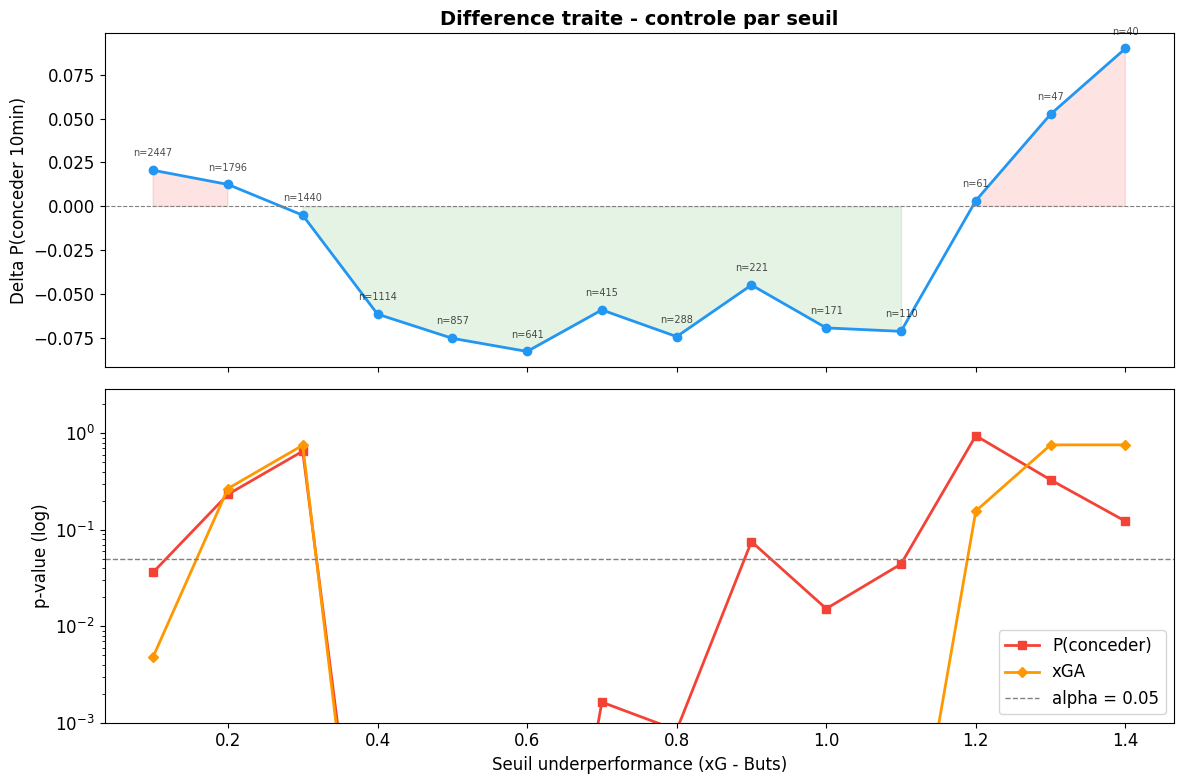

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(sensitivity['threshold'], sensitivity['diff_p_concede'],
             'o-', color='#2196F3', linewidth=2, markersize=6)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].fill_between(sensitivity['threshold'], 0, sensitivity['diff_p_concede'],
                      where=sensitivity['diff_p_concede'] > 0, alpha=0.15, color='#F44336')
axes[0].fill_between(sensitivity['threshold'], 0, sensitivity['diff_p_concede'],
                      where=sensitivity['diff_p_concede'] <= 0, alpha=0.15, color='#4CAF50')
axes[0].set_ylabel('Delta P(conceder 10min)')
axes[0].set_title('Difference traite - controle par seuil')
for _, row in sensitivity.iterrows():
    axes[0].annotate(f'n={int(row["n_treated"])}',
                      (row['threshold'], row['diff_p_concede']),
                      textcoords='offset points', xytext=(0, 10),
                      fontsize=7, ha='center', alpha=0.7)
axes[1].semilogy(sensitivity['threshold'], sensitivity['p_value_concede'],
                  's-', color='#F44336', linewidth=2, markersize=6, label='P(conceder)')
axes[1].semilogy(sensitivity['threshold'], sensitivity['p_value_xga'],
                  'D-', color='#FF9800', linewidth=2, markersize=5, label='xGA')
axes[1].axhline(0.05, color='gray', linestyle='--', linewidth=1, label='alpha = 0.05')
axes[1].set_ylabel('p-value (log)')
axes[1].set_xlabel('Seuil underperformance (xG - Buts)')
axes[1].legend()
axes[1].set_ylim(bottom=0.001)
plt.tight_layout()
plt.savefig('../outputs/figures/03_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Test de permutation

In [12]:
perm_05 = wa.permutation_test(tl, threshold=0.5, window=10, n_permutations=10000)
wa.print_permutation(perm_05)

Permutations: 100%|██████████| 10000/10000 [00:01<00:00, 9047.27it/s]


  TEST DE PERMUTATION (n=10000)
  Seuil            : 0.5
  Diff observee    : -0.07514
  Null mean        : -0.00001
  Null std         : 0.01352
  IC 95% null      : [-0.02709, 0.02646]
  p-value          : 0.0000
  Significatif     : OUI



In [13]:
perm_03 = wa.permutation_test(tl, threshold=0.3, window=10, n_permutations=10000)
wa.print_permutation(perm_03)

Permutations: 100%|██████████| 10000/10000 [00:01<00:00, 6048.14it/s]


  TEST DE PERMUTATION (n=10000)
  Seuil            : 0.3
  Diff observee    : -0.00503
  Null mean        : +0.00016
  Null std         : 0.01117
  IC 95% null      : [-0.02175, 0.02190]
  p-value          : 0.6781
  Significatif     : NON



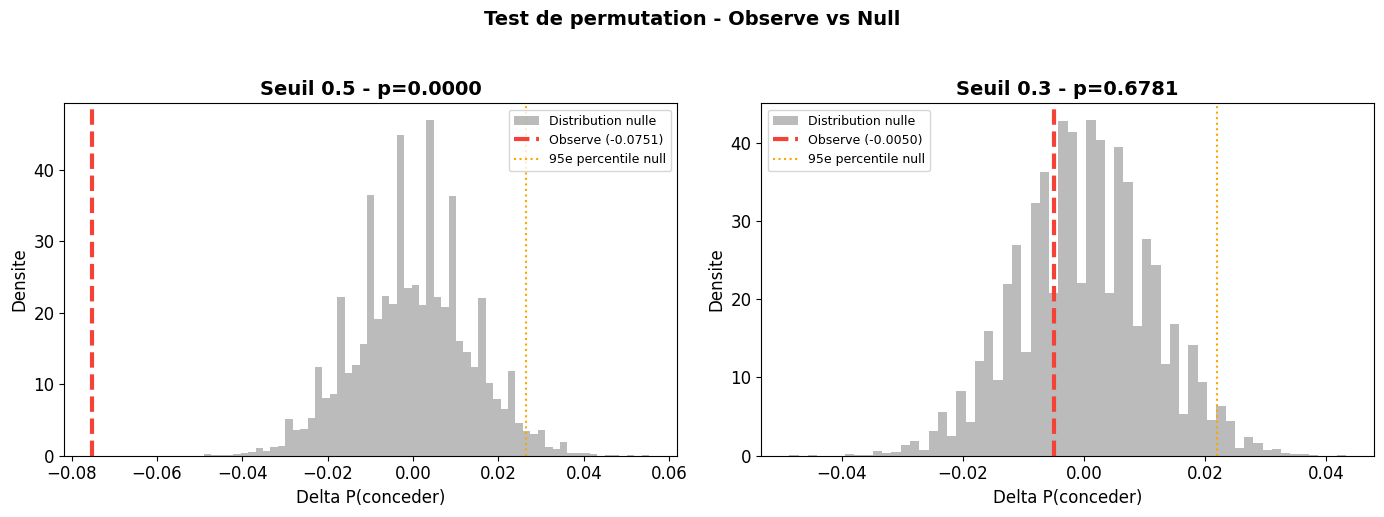

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (perm, thresh) in enumerate([(perm_05, 0.5), (perm_03, 0.3)]):
    ax = axes[i]
    ax.hist(perm['null_distribution'], bins=60, alpha=0.7,
            color='#9E9E9E', density=True, label='Distribution nulle')
    ax.axvline(perm['observed_diff'], color='#F44336', linewidth=3,
               linestyle='--', label=f'Observe ({perm["observed_diff"]:+.4f})')
    ax.axvline(perm['ci_95_null'][1], color='orange', linewidth=1.5,
               linestyle=':', label='95e percentile null')
    ax.set_title(f'Seuil {thresh} - p={perm["p_value"]:.4f}')
    ax.set_xlabel('Delta P(conceder)')
    ax.set_ylabel('Densite')
    ax.legend(fontsize=9)
plt.suptitle('Test de permutation - Observe vs Null', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/03_permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Correction tests multiples

In [15]:
all_pvalues = list(sensitivity['p_value_concede']) + list(sensitivity['p_value_xga'])
corrected_p, reject = wa.correct_multiple_tests(all_pvalues)
n_tests = len(sensitivity)
sensitivity = sensitivity.copy()
sensitivity['p_corrected_concede'] = corrected_p[:n_tests]
sensitivity['p_corrected_xga'] = corrected_p[n_tests:]
sensitivity['sig_corrected_concede'] = reject[:n_tests]
sensitivity['sig_corrected_xga'] = reject[n_tests:]
print('Apres correction Benjamini-Hochberg :')
print()
display_cols = ['threshold', 'diff_p_concede', 'p_value_concede',
                'p_corrected_concede', 'sig_corrected_concede', 'n_treated']
print(sensitivity[display_cols].to_string(index=False))

Apres correction Benjamini-Hochberg :

 threshold  diff_p_concede  p_value_concede  p_corrected_concede  sig_corrected_concede  n_treated
       0.1        0.020569     3.627966e-02         6.348941e-02                  False       2447
       0.2        0.012488     2.329374e-01         3.105832e-01                  False       1796
       0.3       -0.005034     6.528970e-01         7.617131e-01                  False       1440
       0.4       -0.061381     5.608794e-07         2.575059e-06                   True       1114
       0.5       -0.075145     3.357076e-08         4.699907e-07                   True        857
       0.6       -0.082627     8.024368e-08         7.489410e-07                   True        641
       0.7       -0.058973     1.632911e-03         3.517040e-03                   True        415
       0.8       -0.074174     8.382465e-04         1.955909e-03                   True        288
       0.9       -0.044796     7.543720e-02         1.173468e-01      

---
## 6. Heatmap conditionnelle

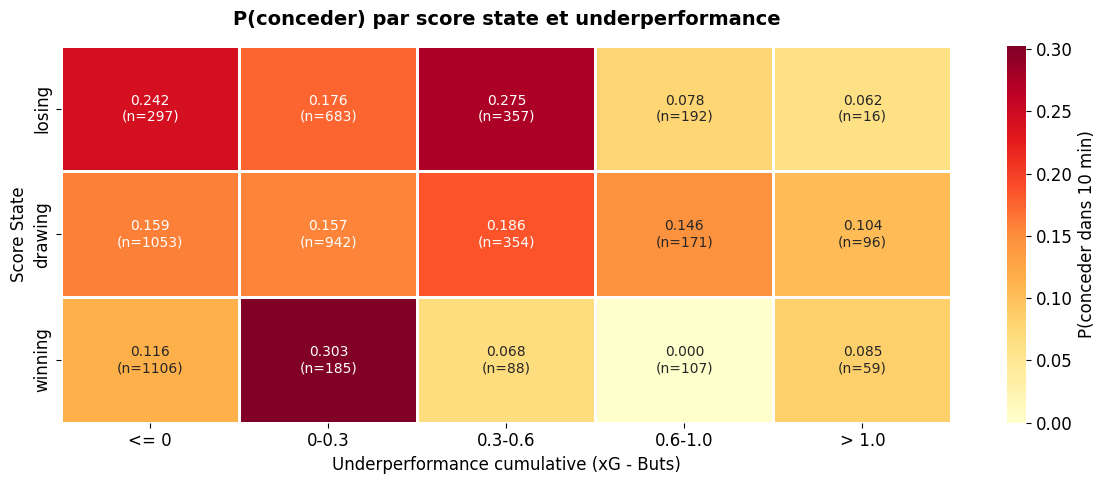

In [16]:
tl_heat = tl.copy()
tl_heat['underperf_bin'] = pd.cut(
    tl_heat['cum_underperf'],
    bins=[-np.inf, 0, 0.3, 0.6, 1.0, np.inf],
    labels=['<= 0', '0-0.3', '0.3-0.6', '0.6-1.0', '> 1.0']
)
pivot_concede = tl_heat.groupby(
    ['score_state', 'underperf_bin'], observed=True
)['future_conceded_10min'].mean().unstack()
pivot_n = tl_heat.groupby(
    ['score_state', 'underperf_bin'], observed=True
)['future_conceded_10min'].count().unstack()
annot = pivot_concede.copy().astype(str)
for col in pivot_concede.columns:
    for idx in pivot_concede.index:
        try:
            val = pivot_concede.loc[idx, col]
            n = pivot_n.loc[idx, col]
            if pd.notna(val):
                annot.loc[idx, col] = f'{val:.3f}\n(n={int(n)})'
            else:
                annot.loc[idx, col] = ''
        except:
            annot.loc[idx, col] = ''
order = ['losing', 'drawing', 'winning']
pivot_concede = pivot_concede.reindex([s for s in order if s in pivot_concede.index])
annot = annot.reindex([s for s in order if s in annot.index])
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_concede, annot=annot, fmt='', cmap='YlOrRd',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'P(conceder dans 10 min)'}, vmin=0,
            annot_kws={'fontsize': 10})
ax.set_title('P(conceder) par score state et underperformance',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score State')
ax.set_xlabel('Underperformance cumulative (xG - Buts)')
plt.tight_layout()
plt.savefig('../outputs/figures/03_heatmap_conditional.png', dpi=200, bbox_inches='tight')
plt.show()

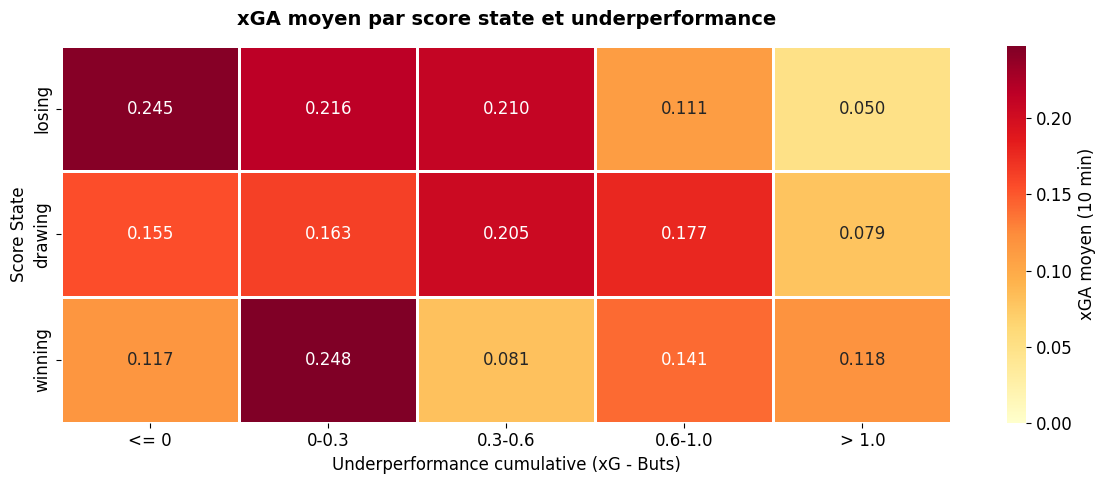

In [17]:
pivot_xga = tl_heat.groupby(
    ['score_state', 'underperf_bin'], observed=True
)['future_xga_10min'].mean().unstack()
pivot_xga = pivot_xga.reindex([s for s in order if s in pivot_xga.index])
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_xga, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=1, linecolor='white', ax=ax,
            cbar_kws={'label': 'xGA moyen (10 min)'}, vmin=0)
ax.set_title('xGA moyen par score state et underperformance',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score State')
ax.set_xlabel('Underperformance cumulative (xG - Buts)')
plt.tight_layout()
plt.savefig('../outputs/figures/03_heatmap_xga.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 7. Fenetre 5 min (robustesse)

In [18]:
tl_5 = feat.filter_complete_windows(timeline, window=5)
results_05_w5 = wa.event_study(tl_5, threshold=0.5, window=5)
wa.print_event_study(results_05_w5, label='FENETRE 5 MIN - Seuil 0.5')
results_03_w5 = wa.event_study(tl_5, threshold=0.3, window=5)
wa.print_event_study(results_03_w5, label='FENETRE 5 MIN - Seuil 0.3')

16:26:36 │ INFO    │ Filtrage fenetre 5min : 350 obs. tronquees supprimees (5.5%)



  FENETRE 5 MIN - Seuil 0.5

  P(conceder dans 10 min) :
    Traite   : 0.0538  (n=966)
    Controle : 0.0898  (n=5090)
    Diff     : -0.0360  (RR=0.600)
    z=-3.692, p=0.0002 *

  xGA moyen (10 min) :
    Traite   : 0.0681
    Controle : 0.0864
    Diff     : -0.0184  (Cohen's d=-0.110)
    t=-3.393, p=0.0007 *

  Tirs adverses (10 min) :
    Traite   : 0.572
    Controle : 0.655
    Diff     : -0.083
    t=-2.914, p=0.0036 *

  FENETRE 5 MIN - Seuil 0.3

  P(conceder dans 10 min) :
    Traite   : 0.0864  (n=1585)
    Controle : 0.0832  (n=4471)
    Diff     : +0.0032  (RR=1.039)
    z=0.399, p=0.6902 

  xGA moyen (10 min) :
    Traite   : 0.0838
    Controle : 0.0834
    Diff     : +0.0004  (Cohen's d=0.002)
    t=0.082, p=0.9344 

  Tirs adverses (10 min) :
    Traite   : 0.585
    Controle : 0.662
    Diff     : -0.077
    t=-3.146, p=0.0017 *


---
## 8. Resume final

In [21]:
print('\n' + '=' * 70)
print('  RESUME PHASE 3')
print('=' * 70)
print('\n1. TEST BRUT (seuil 0.5, fenetre 10min) :')
if results_05:
    c = results_05['concede']
    print(f'   Delta P(conceder) = {c["difference"]:+.4f}, p = {c["p_value"]:.4f}')
print('\n2. STRATIFICATION PAR SCORE STATE (seuil 0.5) :')
for state, res in strat_05.items():
    if res.get('skipped'):
        print(f'   {state:8s} : SKIP')
    else:
        c = res['concede']
        sig = '***' if c['p_value'] < 0.001 else '**' if c['p_value'] < 0.01 else '*' if c['p_value'] < 0.05 else ''
        print(f'   {state:8s} : Delta = {c["difference"]:+.4f}, p = {c["p_value"]:.4f} {sig}')
print('\n3. TEST DE PERMUTATION :')
print(f'   Seuil 0.5 : p = {perm_05["p_value"]:.4f}')
print(f'   Seuil 0.3 : p = {perm_03["p_value"]:.4f}')
print('\n4. SENSIBILITE AU SEUIL :')
n_sig = sensitivity['sig_corrected_concede'].sum()
print(f'   {n_sig}/{len(sensitivity)} seuils significatifs apres correction BH')
print('\n' + '=' * 70)
print('  -> Phase 4 : modelisation avancee + null model Bernoulli')


  RESUME PHASE 3

1. TEST BRUT (seuil 0.5, fenetre 10min) :
   Delta P(conceder) = -0.0751, p = 0.0000

2. STRATIFICATION PAR SCORE STATE (seuil 0.5) :
   drawing  : Delta = -0.0412, p = 0.0440 *
   winning  : Delta = -0.1146, p = 0.0000 ***
   losing   : Delta = -0.1091, p = 0.0000 ***

3. TEST DE PERMUTATION :
   Seuil 0.5 : p = 0.0000
   Seuil 0.3 : p = 0.6781

4. SENSIBILITE AU SEUIL :
   6/14 seuils significatifs apres correction BH

  -> Phase 4 : modelisation avancee + null model Bernoulli


---
## Prochaines etapes : Phase 4
- Regression logistique avec controles
- Analyse de survie (Cox PH, Kaplan-Meier)
- **Null model simulation (Bernoulli)** = test cle